# Extraction Statistics for Chunking Strategy

This notebook analyzes the final parsed section file and produces statistics that help decide a chunking strategy.

It focuses on:
- section size and hierarchy
- block composition
- table presence
- estimated token lengths
- leaf-section behavior
- simple chunking simulations under multiple token budgets

**Expected input structure**: the final section JSON list with:
`section_id`, `parent_section_id`, `doc_id`, `doc_version`, `doc_date`, `title`, `section_number`, `level`, `parent_titles`, `start_page`, `end_page`, `start_top`, `end_top`, `child_section_ids`, `blocks`, `tables`


In [1]:
! pip install matplotlib

In [2]:
# Imports
import json
import math
import re
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


## 1) Load the parsed sections file

Update `SECTIONS_PATH` if needed. The notebook assumes a JSON file containing a list of section objects.


In [3]:
# Path config
SECTIONS_PATH = Path("../../../data/processed/book4/done/final_chunk_ready.json")

with open(SECTIONS_PATH, "r", encoding="utf-8") as f:
    sections = json.load(f)

print(f"Loaded {len(sections)} sections from: {SECTIONS_PATH}")


Loaded 131 sections from: ../../../data/processed/book4/done/final_chunk_ready.json


## 2) Helper functions

These helpers convert blocks and tables into analysis-ready text and estimate approximate token counts.


In [4]:
def normalize_ws(s):
    return re.sub(r"\s+", " ", str(s or "")).strip()

def approx_tokens(text):
    # Simple approximation for planning only
    # Good enough to compare chunking strategies
    return math.ceil(len(normalize_ws(text)) / 4)

def block_text(block):
    btype = block.get("type")
    if btype == "paragraph":
        return normalize_ws(block.get("text", ""))
    if btype == "bullet_list":
        items = [normalize_ws(x) for x in block.get("items", []) if normalize_ws(x)]
        return "\n".join([f"• {x}" for x in items])
    return ""

def table_text(table):
    parts = []
    if normalize_ws(table.get("title")):
        parts.append(normalize_ws(table.get("title")))
    if normalize_ws(table.get("table_text")):
        parts.append(normalize_ws(table.get("table_text")))
    return "\n".join(parts)

def section_text(section, include_tables=True):
    parts = []
    for b in section.get("blocks", []):
        txt = block_text(b)
        if txt:
            parts.append(txt)
    if include_tables:
        for t in section.get("tables", []):
            txt = table_text(t)
            if txt:
                parts.append(txt)
    return "\n\n".join(parts)

def is_leaf(section):
    return len(section.get("child_section_ids", [])) == 0


## 3) Build section-level statistics table

In [5]:
rows = []

for sec in sections:
    blocks = sec.get("blocks", [])
    tables = sec.get("tables", [])
    text_only = section_text(sec, include_tables=False)
    full_text = section_text(sec, include_tables=True)

    block_counter = Counter([b.get("type", "unknown") for b in blocks])

    rows.append({
        "section_id": sec.get("section_id"),
        "section_number": sec.get("section_number"),
        "title": sec.get("title"),
        "level": sec.get("level"),
        "parent_section_id": sec.get("parent_section_id"),
        "n_children": len(sec.get("child_section_ids", [])),
        "is_leaf": is_leaf(sec),
        "start_page": sec.get("start_page"),
        "end_page": sec.get("end_page"),
        "page_span": (sec.get("end_page", 0) - sec.get("start_page", 0) + 1),
        "n_blocks": len(blocks),
        "n_tables": len(tables),
        "n_paragraph_blocks": block_counter.get("paragraph", 0),
        "n_bullet_lists": block_counter.get("bullet_list", 0),
        "text_chars": len(text_only),
        "text_tokens_est": approx_tokens(text_only),
        "full_chars": len(full_text),
        "full_tokens_est": approx_tokens(full_text),
    })

df = pd.DataFrame(rows)
df.head()


,section_id,section_number,title,level,parent_section_id,n_children,is_leaf,start_page,end_page,page_span,n_blocks,n_tables,n_paragraph_blocks,n_bullet_lists,text_chars,text_tokens_est,full_chars,full_tokens_est
0,EMV_Book_2_v4.4_11_Part_I,Part I,General,0,None,4,False,11,36,26,1,0,1,0,7,2,7,2
1,EMV_Book_2_v4.4_12_PartI.1,PartI.1,Scope,1,EMV_Book_2_v4.4_11_Part_I,4,False,12,14,3,2,0,1,1,604,151,604,151
2,EMV_Book_2_v4.4_12_PartI.1.1,PartI.1.1,Changes in Version 4.4,2,EMV_Book_2_v4.4_12_PartI.1,0,True,12,12,1,2,0,2,0,252,63,252,63
3,EMV_Book_2_v4.4_12_PartI.1.2,PartI.1.2,Structure,2,EMV_Book_2_v4.4_12_PartI.1,0,True,12,13,2,20,0,17,3,2686,667,2686,667
4,EMV_Book_2_v4.4_13_PartI.1.3,PartI.1.3,Underlying Standards,2,EMV_Book_2_v4.4_12_PartI.1,0,True,13,13,1,1,0,1,0,268,67,268,67


## 4) Global summary

In [6]:
summary = {
    "n_sections": int(len(df)),
    "n_leaf_sections": int(df["is_leaf"].sum()),
    "n_non_leaf_sections": int((~df["is_leaf"]).sum()),
    "n_sections_with_tables": int((df["n_tables"] > 0).sum()),
    "n_sections_with_bullets": int((df["n_bullet_lists"] > 0).sum()),
    "total_blocks": int(df["n_blocks"].sum()),
    "total_tables": int(df["n_tables"].sum()),
    "median_section_tokens_text_only": float(df["text_tokens_est"].median()),
    "median_section_tokens_with_tables": float(df["full_tokens_est"].median()),
    "p90_section_tokens_with_tables": float(df["full_tokens_est"].quantile(0.90)),
    "max_section_tokens_with_tables": int(df["full_tokens_est"].max()),
}
pd.DataFrame([summary]).T.rename(columns={0: "value"})


,value
n_sections,131.0
n_leaf_sections,100.0
n_non_leaf_sections,31.0
n_sections_with_tables,31.0
n_sections_with_bullets,39.0
total_blocks,1077.0
total_tables,58.0
median_section_tokens_text_only,166.0
median_section_tokens_with_tables,207.0
p90_section_tokens_with_tables,780.0


## 5) Distribution by hierarchy level

In [7]:
level_stats = (
    df.groupby("level")
      .agg(
          n_sections=("section_id", "count"),
          leaf_sections=("is_leaf", "sum"),
          median_tokens=("full_tokens_est", "median"),
          p90_tokens=("full_tokens_est", lambda s: s.quantile(0.90)),
          max_tokens=("full_tokens_est", "max"),
          avg_blocks=("n_blocks", "mean"),
          avg_tables=("n_tables", "mean"),
      )
      .reset_index()
)

display(level_stats)


,level,n_sections,leaf_sections,median_tokens,p90_tokens,max_tokens,avg_blocks,avg_tables
0,0,5,0,5.0,174.0,286,1.200000,0.000000
1,1,20,7,111.5,1010.6,2998,14.100000,0.250000
2,2,53,43,243.0,853.6,1882,10.566038,0.603774
3,3,44,41,213.5,598.1,931,3.772727,0.431818
4,4,9,9,295.0,1444.4,1466,7.000000,0.222222


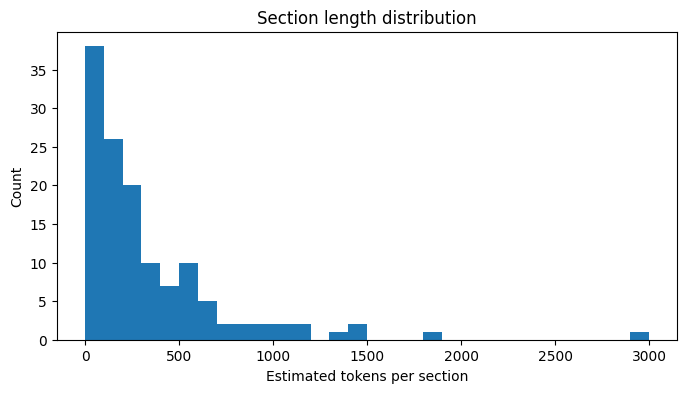

In [8]:
plt.figure(figsize=(8,4))
df["full_tokens_est"].plot(kind="hist", bins=30)
plt.xlabel("Estimated tokens per section")
plt.ylabel("Count")
plt.title("Section length distribution")
plt.show()


## 6) Focus on leaf sections

Leaf sections are usually the best default unit for chunking, so they deserve separate analysis.


In [9]:
leaf_df = df[df["is_leaf"]].copy()

leaf_summary = {
    "n_leaf_sections": int(len(leaf_df)),
    "median_leaf_tokens": float(leaf_df["full_tokens_est"].median()) if len(leaf_df) else 0,
    "p75_leaf_tokens": float(leaf_df["full_tokens_est"].quantile(0.75)) if len(leaf_df) else 0,
    "p90_leaf_tokens": float(leaf_df["full_tokens_est"].quantile(0.90)) if len(leaf_df) else 0,
    "max_leaf_tokens": int(leaf_df["full_tokens_est"].max()) if len(leaf_df) else 0,
}
pd.DataFrame([leaf_summary]).T.rename(columns={0: "value"})


,value
n_leaf_sections,100.0
median_leaf_tokens,246.0
p75_leaf_tokens,547.0
p90_leaf_tokens,937.5
max_leaf_tokens,2998.0


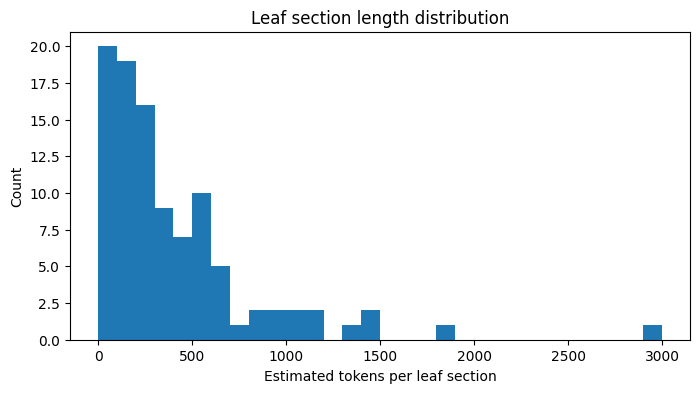

In [10]:
plt.figure(figsize=(8,4))
leaf_df["full_tokens_est"].plot(kind="hist", bins=30)
plt.xlabel("Estimated tokens per leaf section")
plt.ylabel("Count")
plt.title("Leaf section length distribution")
plt.show()


## 7) Longest sections

These sections are the main reason adaptive chunking may be needed.


In [11]:
longest_sections = (
    df.sort_values("full_tokens_est", ascending=False)
      [["section_number", "title", "level", "is_leaf", "n_blocks", "n_tables", "full_tokens_est"]]
      .head(20)
)

display(longest_sections)


,section_number,title,level,is_leaf,n_blocks,n_tables,full_tokens_est
7,PartI.3,Definitions,1,True,161,0,2998
130,PartV.E3,Example 3 Vending Machine,2,True,55,1,1882
25,PartII.6.3.2.2,XDA,4,True,32,0,1466
32,PartII.6.3.4.5,CVM Results,4,True,9,2,1439
9,PartI.4.1,Abbreviations,2,True,178,0,1363
112,PartV.A3,Additional Terminal Capabilities,2,True,19,5,1177
6,PartI.2,Normative References,1,True,76,0,1142
89,PartIV.11.2,Standard Messages 8,2,True,8,2,1053
85,PartIII.10.2,Application Dependent Data,2,True,8,2,1025
118,PartV.Annex C,Example Data Element Conversion,1,True,10,3,996


## 8) Block-level statistics

This helps decide whether chunking should be section-based, block-based, or mixed.


In [12]:
block_rows = []

for sec in sections:
    for blk in sec.get("blocks", []):
        txt = block_text(blk)
        block_rows.append({
            "section_id": sec.get("section_id"),
            "section_number": sec.get("section_number"),
            "level": sec.get("level"),
            "block_id": blk.get("block_id"),
            "type": blk.get("type"),
            "page_num": blk.get("page_num"),
            "chars": len(txt),
            "tokens_est": approx_tokens(txt),
        })

block_df = pd.DataFrame(block_rows)
block_df.head()


,section_id,section_number,level,block_id,type,page_num,chars,tokens_est
0,EMV_Book_2_v4.4_11_Part_I,Part I,0,Part I_b1,paragraph,11,7,2
1,EMV_Book_2_v4.4_12_PartI.1,PartI.1,1,PartI.1_b1,paragraph,12,453,114
2,EMV_Book_2_v4.4_12_PartI.1,PartI.1,1,PartI.1_b2,bullet_list,12,149,38
3,EMV_Book_2_v4.4_12_PartI.1.1,PartI.1.1,2,PartI.1.1_b1,paragraph,12,141,36
4,EMV_Book_2_v4.4_12_PartI.1.1,PartI.1.1,2,PartI.1.1_b2,paragraph,12,109,28


In [13]:
block_type_stats = (
    block_df.groupby("type")
            .agg(
                n_blocks=("block_id", "count"),
                median_tokens=("tokens_est", "median"),
                p90_tokens=("tokens_est", lambda s: s.quantile(0.90)),
                max_tokens=("tokens_est", "max"),
            )
            .reset_index()
)
display(block_type_stats)


,type,n_blocks,median_tokens,p90_tokens,max_tokens
0,bullet_list,60,63.5,237.8,344
1,paragraph,1017,17.0,72.0,236


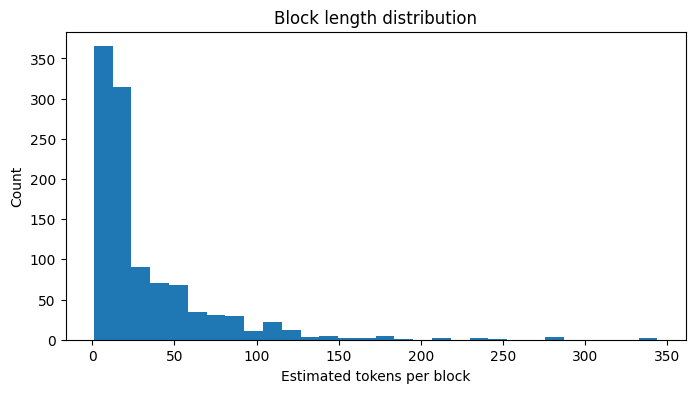

In [14]:
plt.figure(figsize=(8,4))
block_df["tokens_est"].plot(kind="hist", bins=30)
plt.xlabel("Estimated tokens per block")
plt.ylabel("Count")
plt.title("Block length distribution")
plt.show()


## 9) Table statistics

Tables often need special handling because they can become oversized or should remain atomic.


In [15]:
table_rows = []

for sec in sections:
    for tb in sec.get("tables", []):
        txt = table_text(tb)
        table_rows.append({
            "section_id": sec.get("section_id"),
            "section_number": sec.get("section_number"),
            "title": tb.get("title"),
            "table_id": tb.get("table_id"),
            "page_num": tb.get("page_num"),
            "chars": len(txt),
            "tokens_est": approx_tokens(txt),
            "n_rows_raw": len(tb.get("cells", [])) if isinstance(tb.get("cells"), list) else None,
        })

table_df = pd.DataFrame(table_rows)
table_df.head() if len(table_df) else table_df


,section_id,section_number,title,table_id,page_num,chars,tokens_est,n_rows_raw
0,EMV_Book_2_v4.4_38_PartII.5.1,PartII.5.1,Table 1: Terms Describing Terminal Types,p0038_t01,38,1071,268,7
1,EMV_Book_2_v4.4_40_PartII.5.3,PartII.5.3,Table 1: Terms Describing Terminal Types,p0040_t01,40,293,74,8
2,EMV_Book_2_v4.4_40_PartII.5.3,PartII.5.3,Table 1: Terms Describing Terminal Types,p0041_t01,41,170,43,7
3,EMV_Book_2_v4.4_40_PartII.5.3,PartII.5.3,Table 1: Terms Describing Terminal Types,p0042_t01,42,460,115,4
4,EMV_Book_2_v4.4_40_PartII.5.3,PartII.5.3,Table 1: Terms Describing Terminal Types,p0042_t02,42,52,13,2


,table_tokens_est
count,58.000000
mean,172.655172
std,120.860882
min,10.000000
25%,75.500000
50%,143.000000
75%,264.500000
max,477.000000


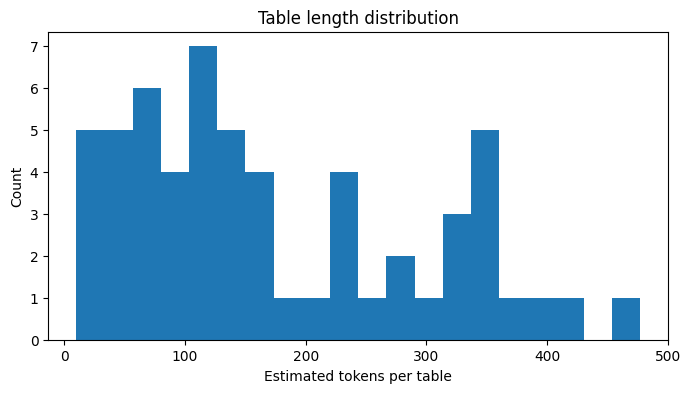

In [16]:
if len(table_df):
    display(
        table_df["tokens_est"].describe().to_frame("table_tokens_est")
    )
    plt.figure(figsize=(8,4))
    table_df["tokens_est"].plot(kind="hist", bins=20)
    plt.xlabel("Estimated tokens per table")
    plt.ylabel("Count")
    plt.title("Table length distribution")
    plt.show()
else:
    print("No tables found.")


## 10) Chunking simulation

This is a planning simulation, not the final chunking step.

It estimates how many chunks would be created if:
- leaf sections under a token budget stay intact
- longer sections are split by accumulated blocks
- tables remain atomic


In [17]:
def iter_units(section):
    # Text blocks first
    for blk in section.get("blocks", []):
        txt = block_text(blk)
        if txt:
            yield {
                "unit_type": "block",
                "unit_id": blk.get("block_id"),
                "tokens_est": approx_tokens(txt),
            }
    # Tables as atomic units
    for tb in section.get("tables", []):
        txt = table_text(tb)
        if txt:
            yield {
                "unit_type": "table",
                "unit_id": tb.get("table_id"),
                "tokens_est": approx_tokens(txt),
            }

def simulate_chunks(section, token_budget=400):
    units = list(iter_units(section))
    if not units:
        return 0

    chunks = 1
    current = 0

    for u in units:
        t = u["tokens_est"]

        # Atomic oversized unit still gets its own chunk
        if t > token_budget:
            if current > 0:
                chunks += 1
            current = 0
            chunks += 1
            continue

        if current + t <= token_budget:
            current += t
        else:
            chunks += 1
            current = t

    return chunks

budgets = [256, 384, 512, 768]

sim_rows = []
for sec in sections:
    row = {
        "section_id": sec.get("section_id"),
        "section_number": sec.get("section_number"),
        "title": sec.get("title"),
        "is_leaf": is_leaf(sec),
        "full_tokens_est": approx_tokens(section_text(sec, include_tables=True)),
    }
    for b in budgets:
        row[f"chunks_at_{b}"] = simulate_chunks(sec, token_budget=b)
    sim_rows.append(row)

sim_df = pd.DataFrame(sim_rows)
sim_df.head()


,section_id,section_number,title,is_leaf,full_tokens_est,chunks_at_256,chunks_at_384,chunks_at_512,chunks_at_768
0,EMV_Book_2_v4.4_11_Part_I,Part I,General,False,2,1,1,1,1
1,EMV_Book_2_v4.4_12_PartI.1,PartI.1,Scope,False,151,1,1,1,1
2,EMV_Book_2_v4.4_12_PartI.1.1,PartI.1.1,Changes in Version 4.4,True,63,1,1,1,1
3,EMV_Book_2_v4.4_12_PartI.1.2,PartI.1.2,Structure,True,667,3,2,2,1
4,EMV_Book_2_v4.4_13_PartI.1.3,PartI.1.3,Underlying Standards,True,67,1,1,1,1


In [18]:
simulation_summary = []
for b in budgets:
    c = f"chunks_at_{b}"
    simulation_summary.append({
        "token_budget": b,
        "total_chunks": int(sim_df[c].sum()),
        "median_chunks_per_section": float(sim_df[c].median()),
        "sections_split": int((sim_df[c] > 1).sum()),
        "leaf_sections_split": int(((sim_df["is_leaf"]) & (sim_df[c] > 1)).sum()),
    })

simulation_summary_df = pd.DataFrame(simulation_summary)
display(simulation_summary_df)


,token_budget,total_chunks,median_chunks_per_section,sections_split,leaf_sections_split
0,256,258,1.0,53,48
1,384,197,1.0,38,37
2,512,172,1.0,30,29
3,768,144,1.0,14,13


## 11) Recommendation helper

This cell gives a simple recommendation based on the observed distributions.


In [19]:
def recommend_strategy(df, leaf_df, simulation_summary_df):
    median_leaf = leaf_df["full_tokens_est"].median() if len(leaf_df) else 0
    p90_leaf = leaf_df["full_tokens_est"].quantile(0.90) if len(leaf_df) else 0
    sections_with_tables = int((df["n_tables"] > 0).sum())
    sections_with_bullets = int((df["n_bullet_lists"] > 0).sum())

    print("Suggested strategy:")
    print("- Default chunk unit: leaf section")
    print("- Preserve tables as atomic chunks")
    print("- Keep bullet lists with surrounding context when possible")
    print("- Use adaptive splitting only for long sections")

    if p90_leaf <= 400:
        print("- A target around 384–400 tokens looks realistic for most leaf sections.")
    elif p90_leaf <= 512:
        print("- A target around 450–512 tokens looks realistic for most leaf sections.")
    else:
        print("- Many leaf sections are long, so block-based adaptive splitting is important.")

    if sections_with_tables:
        print(f"- {sections_with_tables} sections contain tables, so table-aware chunking is necessary.")
    if sections_with_bullets:
        print(f"- {sections_with_bullets} sections contain bullet lists, so preserve list grouping during chunking.")

recommend_strategy(df, leaf_df, simulation_summary_df)


Suggested strategy:
- Default chunk unit: leaf section
- Preserve tables as atomic chunks
- Keep bullet lists with surrounding context when possible
- Use adaptive splitting only for long sections
- Many leaf sections are long, so block-based adaptive splitting is important.
- 31 sections contain tables, so table-aware chunking is necessary.
- 39 sections contain bullet lists, so preserve list grouping during chunking.


## 12) Export statistics tables

Useful if you want to include these results in a report or compare chunking strategies later.


In [20]:
OUT_DIR = Path("./chunking_stats_outputs/Book4")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUT_DIR / "section_stats.csv", index=False, encoding="utf-8")
level_stats.to_csv(OUT_DIR / "level_stats.csv", index=False, encoding="utf-8")
longest_sections.to_csv(OUT_DIR / "longest_sections.csv", index=False, encoding="utf-8")
block_df.to_csv(OUT_DIR / "block_stats.csv", index=False, encoding="utf-8")
block_type_stats.to_csv(OUT_DIR / "block_type_stats.csv", index=False, encoding="utf-8")
sim_df.to_csv(OUT_DIR / "chunk_simulation_by_section.csv", index=False, encoding="utf-8")
simulation_summary_df.to_csv(OUT_DIR / "chunk_simulation_summary.csv", index=False, encoding="utf-8")
if len(table_df):
    table_df.to_csv(OUT_DIR / "table_stats.csv", index=False, encoding="utf-8")

print(f"Saved outputs to: {OUT_DIR.resolve()}")


Saved outputs to: /app/src/core/notebooks/DataPreprocessing/chunking_stats_outputs/Book4
